# SWGO L07 Detector Optimization — TR (Triangulated) Mountain Surface

v4: detectors slide on the 3D Colca Valley mountain surface.
Learnable parameters: `(x = North, y = Up)` in metres.
Derived: `East = f(N, Up)` via differentiable surface map; `z_cont = (EAST_ENTRY − East) / LAYER_EAST_DX` maps to AllShowers layer index.

Reuses v3 modules via sys.path injection — no verbatim copies.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library imports
import torch
import torch._utils  # workaround: torch 2.x lazy submodule needed by torch.save on Py3.13
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy
import warnings
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import colors
from matplotlib.colors import LogNorm, Normalize
from torch.utils.data import TensorDataset, DataLoader
import os
import gc
import functools

# Suppress noisy warnings that flood SLURM logs
warnings.filterwarnings("ignore", message="num points .* exceeds max points")
torch.set_float32_matmul_precision('highest')

# v3 modules (via sys.path injection in modules_v4/__init__.py)
import modules_v4  # triggers sys.path injection for v3
from modules.generate_showers import GenerateShowers
from modules.shower_computation import ComputeShowerDetection
from modules.detector_response import GetCounts_differentiable, SmearN, TimeAverage_vectorized
from modules.reconstruction import Reconstruction, NormalizeLabels, DenormalizeLabels, EarlyStopping
from modules.layout_optimization import LearnableXY
from modules.utility_functions import reconstructability, U_PR, U_E, U_angle

# v4 new modules
from modules_v4.tr_geometry import load_tr_mountain
from modules_v4.tr_surface_map import SurfaceEastMap
from modules_v4.tr_plane_kernel import GetCounts_planeaware

output_dir = "./outputs/NN_Files_42_20k_shower_mean_U_lr_1"
os.makedirs(output_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

#####################
#  Hyperparameters  #
#####################
generate_new_data = True
use_cache = True
training_epochs = 300

device: cuda


## Constants and Parameters

In [3]:
# Physics constants
c0 = .29979          # Speed of light [m/ns]
theta_max = np.pi * 65 / 180
log_01 = torch.tensor([np.log(.1)], dtype=torch.float32)
log_10 = torch.tensor([np.log(10)], dtype=torch.float32)

# Tank values (same as v3)
IntegrationWindow = 128.   # ns
sigma_time        = 10.    # ns time resolution
TankArea          = 6.859 * np.pi
TankRadius        = np.sqrt(6.859)
R_min             = 2.

# Background
Bgr_e_per_m2 = 0.000000200 * IntegrationWindow
fluxB_e = torch.tensor([TankArea * Bgr_e_per_m2])

# Optimization sizes
Nunits       = 90
RelResCounts = .05
NUM_FEATURES = 5#7   # [x=N, y=Up, z=z_cont, N_int, T_int, x0, y0]

# NN training sizes
Nevents     = 20000 # 0
Nvalidation = 2000 # 0
Ntest       = 300 # 0
Nbatch      = 500 # 0

# Geometry — v4 mountain surface
GEOMETRY_PATH = "../../TAMBOSim/resources/basic_geometry.h5"
GROUP    = "colca_valley_30000"
DET_KEY  = "detector1"
N_PLANES = 24
# AllShowers layer-East calibration (empirically derived from fixture data):
#   East at AllShowers layer k = EAST_ENTRY - k * LAYER_EAST_DX = -212 - 307k metres
#   z_cont = (EAST_ENTRY - East) / LAYER_EAST_DX  (layer 0 = entry, increases going deeper)
EAST_ENTRY    = 1500.0   # m — East at AllShowers layer 0 (shower entry, padding)
LAYER_EAST_DX =  150.0   # m — East depth per AllShowers layer (positive)

mountain = load_tr_mountain(GEOMETRY_PATH, GROUP, DET_KEY,
                            east_entry=EAST_ENTRY, layer_east_dx=LAYER_EAST_DX, n_planes=N_PLANES)
surface  = SurfaceEastMap.from_mountain(mountain, grid_h=256, grid_w=256).to(device)

print(f"Mountain: N=[{mountain.n_min:.0f}, {mountain.n_max:.0f}] m  "
      f"Up=[{mountain.u_min:.0f}, {mountain.u_max:.0f}] m  "
      f"East=[{mountain.east_lo:.0f}, {mountain.east_hi:.0f}] m")
print(f"AllShowers: EAST_ENTRY={mountain.east_entry} m  LAYER_EAST_DX={mountain.layer_east_dx} m  ")
print(f"  z_cont range on mountain surface: [0, {mountain.east_to_z_cont(mountain.east_lo):.1f}]")
print(f"  n_planes={mountain.n_planes}")

# Initial detector layout sampled on the mountain (N, Up) bounding box
N_init, U_init = mountain.sample_initial_layout(n_units=Nunits, scheme="center")
x_det = torch.as_tensor(N_init, dtype=torch.float32, device=device)
y_det = torch.as_tensor(U_init, dtype=torch.float32, device=device)

# Optimization flag
SWGOopt = False

Mountain: N=[-2497, 2474] m  Up=[2442, 3886] m  East=[-2019, 1182] m
AllShowers: EAST_ENTRY=1500.0 m  LAYER_EAST_DX=150.0 m  
  z_cont range on mountain surface: [0, 23.5]
  n_planes=24


## Initialize Shower Generator

In [4]:
generate_showers_instance = GenerateShowers(output_dir=output_dir, device=device, batch_size=30)

## Helper: Wrap GenerateShowers with module dependencies

In [5]:
# Partial-apply physics constants into v3's post-processing callables
_SmearN = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAverage = functools.partial(TimeAverage_vectorized,
                                 IntegrationWindow=IntegrationWindow,
                                 sigma_time=sigma_time)

# ── Shower vertical recenter (same logic as tests/test_shower_heatmap.ipynb) ─
# AllShowers samples are centred around their own Up mean, which sits below the
# mountain face.  Shift them once so the energy-weighted Up centroid lands at
# Y_TARGET inside the mountain bbox.  The shift is computed lazily on the
# first batch and cached so detectors see a stable shower geometry.
#
# Note: ComputeShowerDetection computes X0/Y0 from samples[:, :, 0..1] BEFORE
# calling the kernel callback, so we must also patch Y0 after the call:
# since the shift is a constant added to every Up value, the energy-weighted
# Y0 just shifts by the same constant.
Y_TARGET = mountain.u_min + 0.25 * (mountain.u_max - mountain.u_min)
_y_shift_state = {"value": None}


def _apply_y_shift(samples):
    """Shift samples[:, :, 1] (Up) by a cached offset.  Compute it on first call."""
    if _y_shift_state["value"] is None:
        with torch.no_grad():
            mask = samples[..., 3] > 0
            if mask.any():
                ys = samples[..., 1][mask]
                es = samples[..., 3][mask]
                centroid = float((ys * es).sum() / es.sum())
                _y_shift_state["value"] = float(Y_TARGET) - centroid
                print(f"[generate_showers] Y_SHIFT cached: centroid={centroid:.0f} m  "
                      f"shift={_y_shift_state['value']:+.0f} m  -> target={Y_TARGET:.0f} m")
            else:
                _y_shift_state["value"] = 0.0
    shift = _y_shift_state["value"]
    if shift == 0.0:
        return samples
    samples = samples.clone()
    samples[..., 1] = samples[..., 1] + shift
    return samples


def generate_showers(x_det, y_det, z_cont, log=False, number_of_showers=1,
                     device=device, use_cache=False):
    """Generate showers and compute plane-aware detector counts.

    z_cont : (n_det,) continuous plane index derived from the mountain surface map.
             Captured by the inner closure - callers must pass the current z_cont
             so that gradients flow back through it to (x_det, y_det).

    The shower Up coordinates and Y0 are recentered by a cached y-shift so that
    the energy-weighted shower centre lands at Y_TARGET inside the mountain bbox.
    """
    def _get_counts_planeaware(samples, x_d, y_d):
        samples = _apply_y_shift(samples)
        return GetCounts_planeaware(
            samples, x_d, y_d, z_cont,
            SmearN_fn=_SmearN,
            fluxB_e=fluxB_e.to(samples.device),
            TimeAverage_vectorized_fn=_TimeAverage,
            sigma=400
        )

    out = ComputeShowerDetection(
        x_det, y_det,
        generate_showers_instance,
        _get_counts_planeaware,
        log=log,
        number_of_showers=number_of_showers,
        device=device,
        use_cache=use_cache,
        output_dir=output_dir,
        filter_plane=None,          # v4: all 24 layers reach the kernel
    )

    # ── Patch Y0 to match the y-shifted samples ─────────────────────────────
    # ComputeShowerDetection returns (N, T, X0, Y0, energies, sin_z, cos_z, sin_a, cos_a, labels).
    # X0 is unaffected (we never shift samples[..., 0]); Y0 needs the constant shift.
    shift = _y_shift_state["value"]
    if shift is not None and shift != 0.0:
        out = list(out)
        out[3] = out[3] + shift     # Y0
        out = tuple(out)
    return out

## Visualize Initial Layout

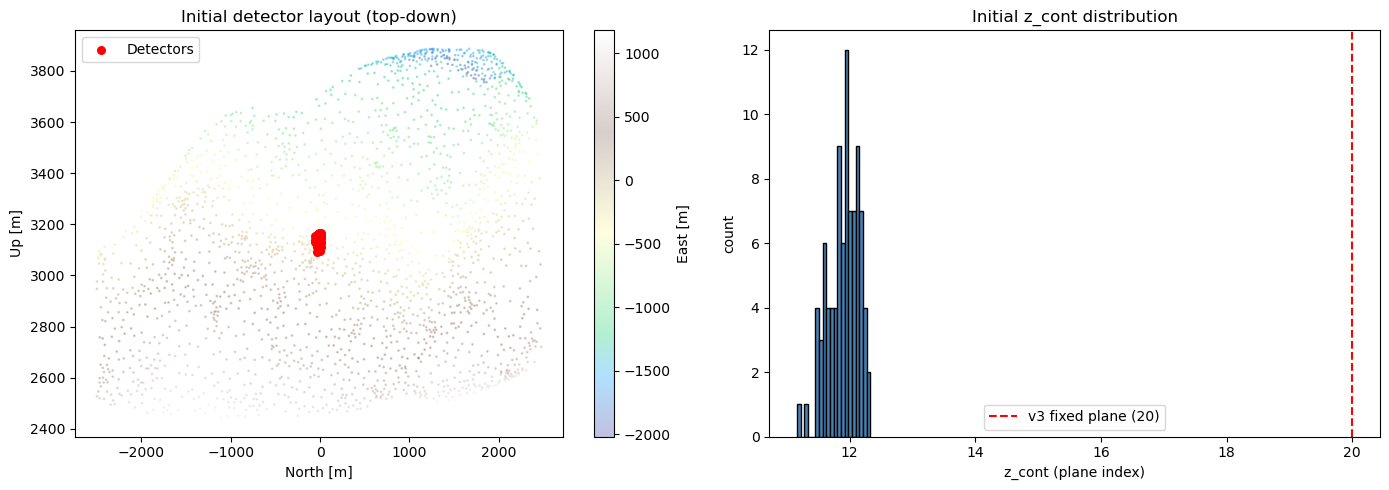

z_cont: min=11.16  max=12.33  mean=11.90


In [6]:
# Compute initial East / z_cont for visualization
with torch.no_grad():
    east_init = surface(x_det, y_det)
    z_cont_init = (mountain.east_entry - east_init) / mountain.layer_east_dx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-down (N, Up) view with mountain surface as background
N_mtn  = mountain.centroids_NUE[:, 0]
Up_mtn = mountain.centroids_NUE[:, 1]
East_mtn = mountain.centroids_NUE[:, 2]
sc0 = axes[0].scatter(N_mtn, Up_mtn, c=East_mtn, s=1, cmap='terrain', alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='East [m]')
axes[0].scatter(x_det.cpu(), y_det.cpu(), c='red', s=30, zorder=5, label='Detectors')
axes[0].set_xlabel("North [m]"); axes[0].set_ylabel("Up [m]")
axes[0].set_title("Initial detector layout (top-down)"); axes[0].legend()

# z_cont distribution
axes[1].hist(z_cont_init.cpu().numpy(), bins=20, color='steelblue', edgecolor='k')
axes[1].set_xlabel("z_cont (plane index)"); axes[1].set_ylabel("count")
axes[1].set_title("Initial z_cont distribution")
axes[1].axvline(20, color='red', linestyle='--', label='v3 fixed plane (20)')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"z_cont: min={z_cont_init.min():.2f}  max={z_cont_init.max():.2f}  mean={z_cont_init.mean():.2f}")

## Generate and Visualize a Single Shower

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 1130.8 ms
  Running inference on 10 samples ...


  Inference done in 1.27 s
  Mean total hits predicted per shower: 1986.2


  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...


  Loaded in 0.26 s
  Time mode: ON (x,y,e,t)
  Generating 10 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[     0s]: start batch   0


/n/home05/zdimitrov/.conda/envs/multiproc_env/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[    73s]: generation done


  Generation done in 73.15 s
samples shape: torch.Size([10, 2048, 5])
  Saved 10 showers → ./outputs/NN_Files_42_20k_shower_mean_U_lr_1/cashed_showers_10.pt


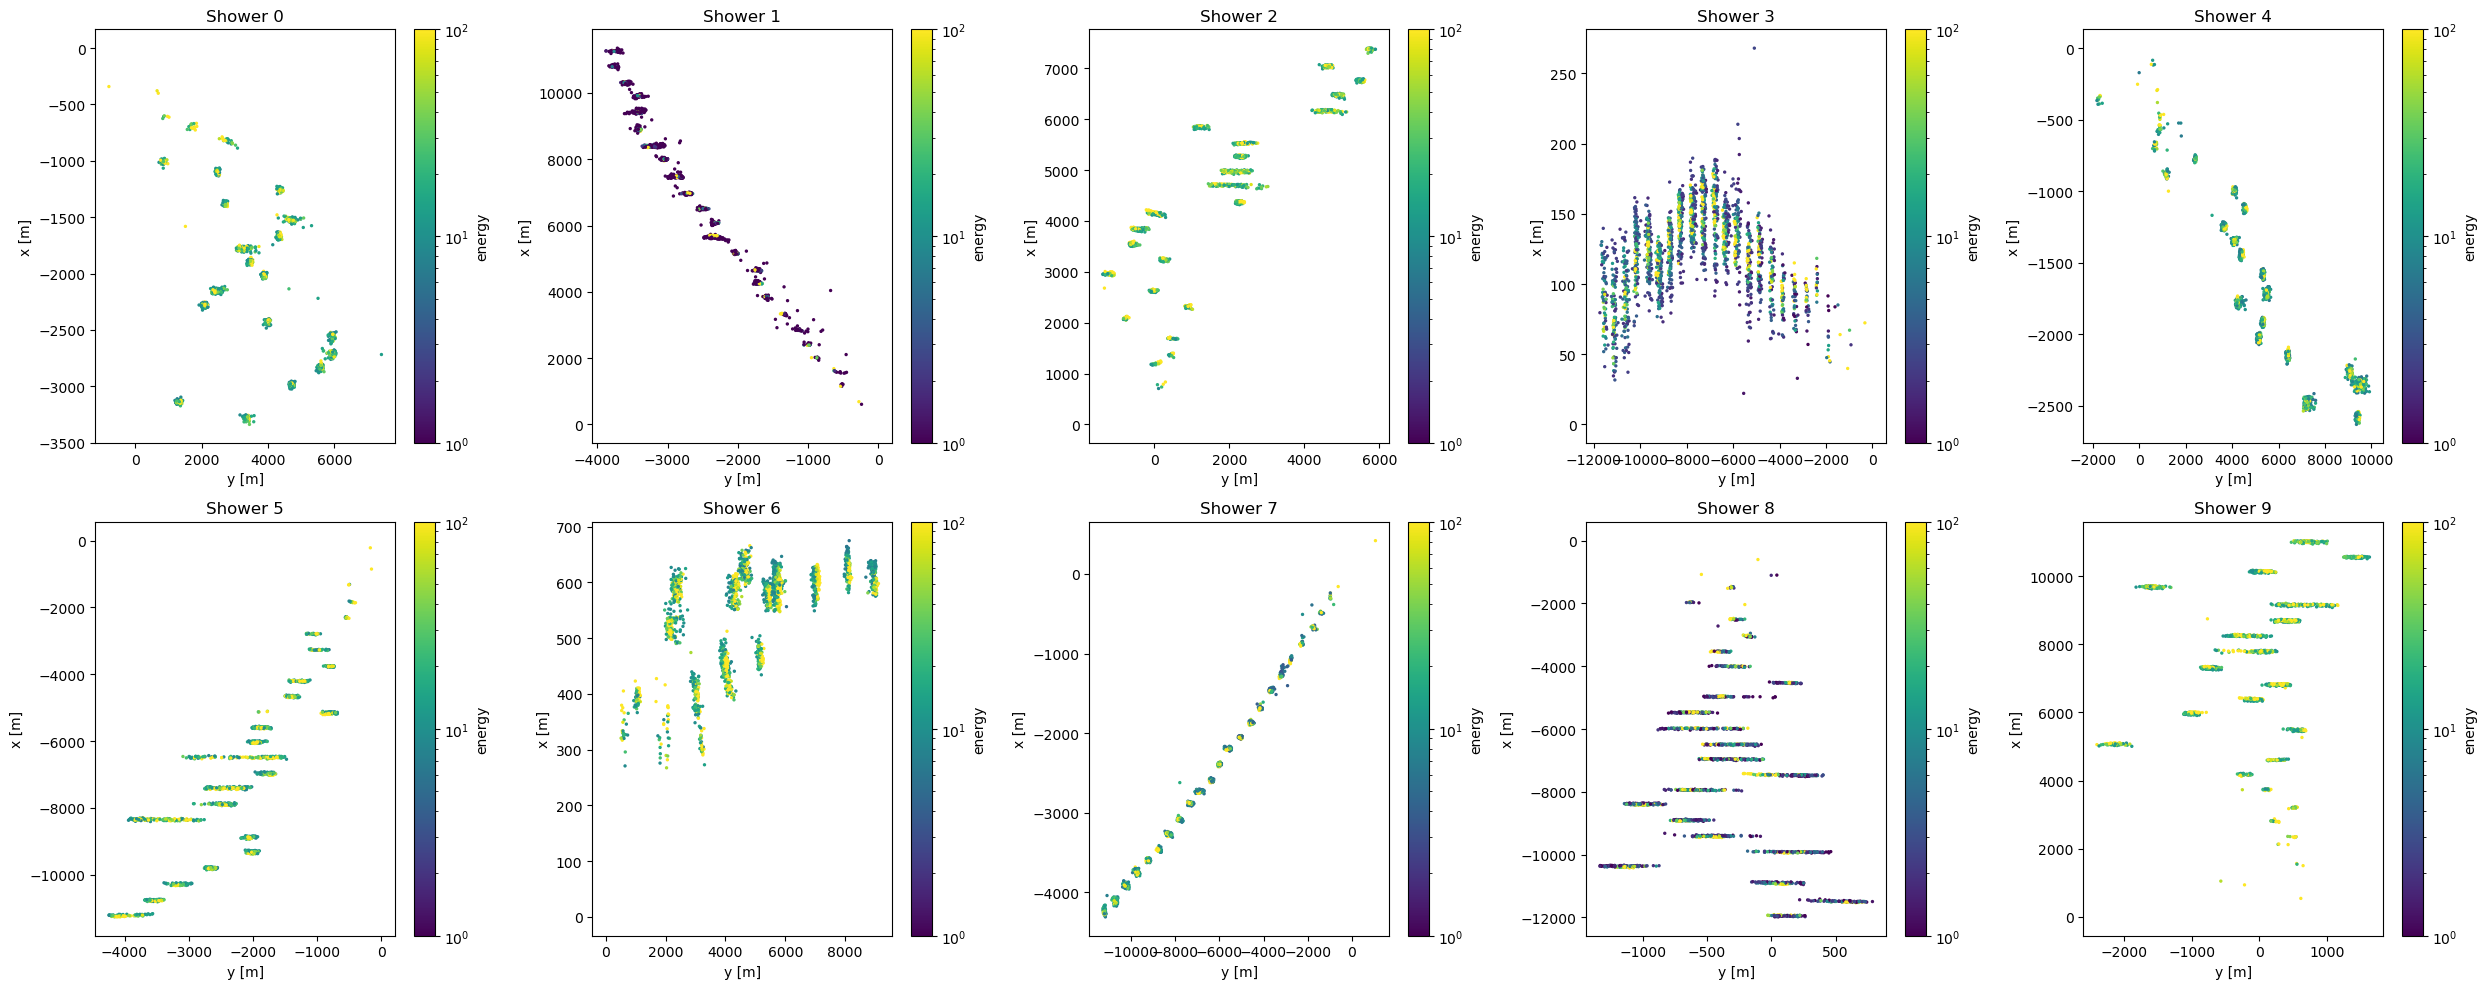

[generate_showers] Y_SHIFT cached: centroid=750 m  shift=+2054 m  -> target=2803 m


In [7]:
SWGOopt = False
with torch.no_grad():
    _z = (mountain.east_entry - surface(x_det, y_det)) / mountain.layer_east_dx
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, labels = generate_showers(
        x_det, y_det, _z, log=True, number_of_showers=10, use_cache=use_cache
    )

In [8]:
print("N:", N.shape)
print("T:", T.shape)
print("X0:", X0)
print("Y0:", Y0)
print("E:", energy.shape)

N: torch.Size([10, 90])
T: torch.Size([10, 90])
X0: 

tensor([-1604.7380,  3374.3696,  3408.9695,    95.1904, -1462.5551, -3614.0972,
          391.9609, -1795.8608, -3697.8601,  3730.5916], device='cuda:0')
Y0: tensor([ 5063.1084,   695.6064,  2314.0776, -1108.6873,  6482.0571,  1029.7974,
         4603.9414, -2519.9121,  1743.7256,  2226.7769], device='cuda:0')
E: torch.Size([10])


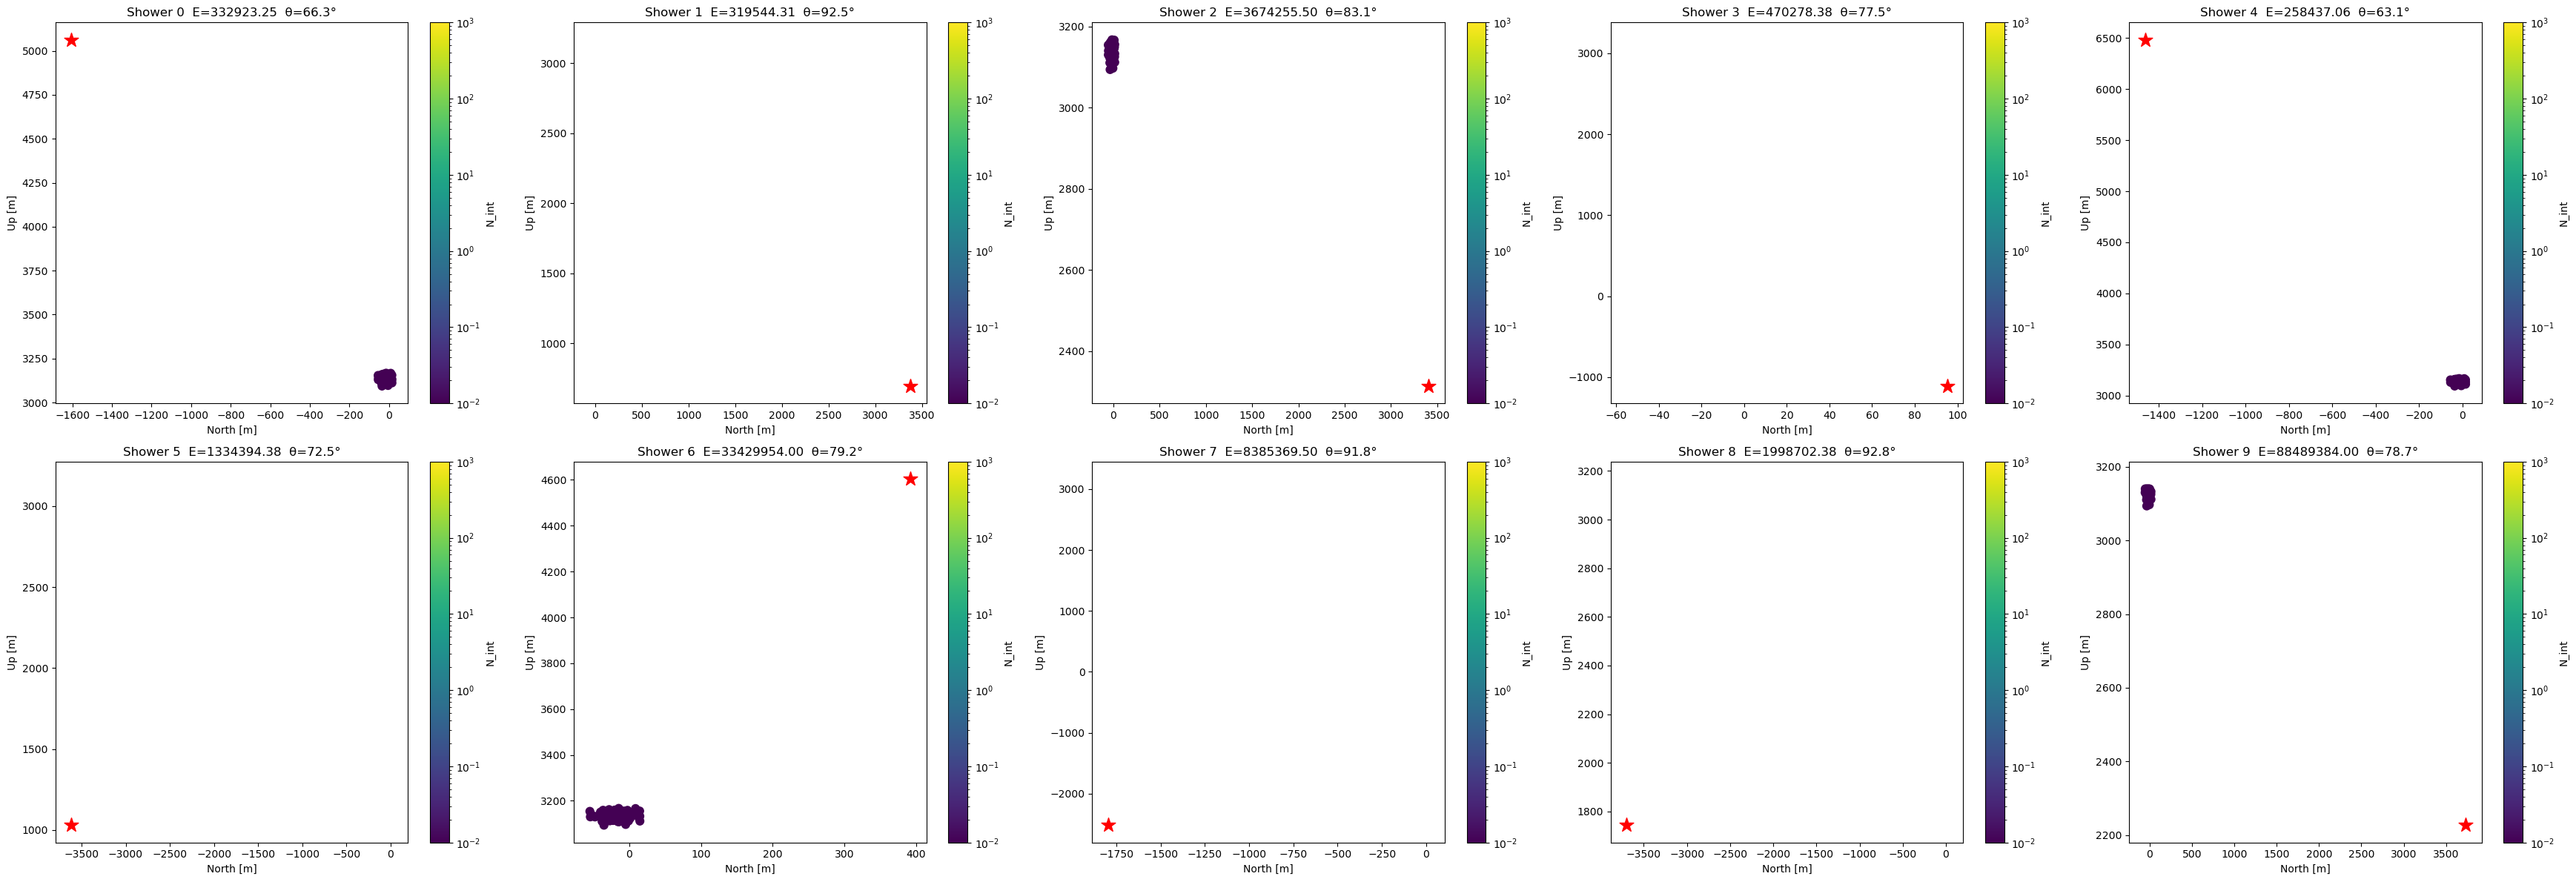

In [9]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i in range(n_events):
    ax = axes[i]
    sc = ax.scatter(x_det.cpu(), y_det.cpu(), c=N[i].detach().cpu(),
                    cmap='viridis', s=60, norm=LogNorm(vmin=1e-2, vmax=1e3))
    fig.colorbar(sc, ax=ax, label='N_int')
    ax.scatter([X0[i].item()], [Y0[i].item()], c='red', marker='*', s=200, label='Core')
    ax.set_xlabel("North [m]"); ax.set_ylabel("Up [m]")
    ax.set_title(f"Shower {i}  E={energy[i]:.2f}  θ={th[i]*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(); plt.show()

## Generate Training Data

In [10]:
print(f"energy.min(): {energy.min():.3f}, energy.max(): {energy.max():.3f}")
print(f"theta.min():  {th.min()*180/np.pi:.1f}°, theta.max():  {th.max()*180/np.pi:.1f}°")
print(f"phi.min():    {ph.min()*180/np.pi:.1f}°, phi.max():    {ph.max()*180/np.pi:.1f}°")

energy.min(): 258437.062, energy.max(): 88489384.000
theta.min():  63.1°, theta.max():  92.8°
phi.min():    -170.5°, phi.max():    171.6°


In [11]:
%%time

if generate_new_data:
    with torch.no_grad():
        _z = (mountain.east_entry - surface(x_det, y_det)) / mountain.layer_east_dx
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(
        x_det, y_det, _z, False, number_of_showers=Nevents, use_cache=use_cache
    )

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)
    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)

    x0 = X0 / 5000
    y0 = Y0 / 5000
    z_exp   = _z.unsqueeze(0).expand(Nevents, -1)
    x_det_exp = x_det.unsqueeze(0).expand(Nevents, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nevents, -1)
    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    # 7 features: [x=N, y=Up, z=z_cont, N_int, T_int, x0, y0]
    # inputs = torch.stack([x_det_exp, y_det_exp, z_exp, N, T, x0_exp, y0_exp], dim=2).float()
    inputs = torch.stack([x_det_exp, y_det_exp, z_exp, N, T], dim=2).float()
    labels = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs, f"{output_dir}/inputs.pt")
    torch.save(labels, f"{output_dir}/labels.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 839.2 ms
  Running inference on 20000 samples ...


  Inference done in 24.58 s
  Mean total hits predicted per shower: 1991.5
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.06 s
  Time mode: ON (x,y,e,t)
  Generating 20000 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   119s]: start batch   0


[   154s]: start batch   1


[   154s]: start batch   2


...

[   438s]: start batch 666


[   439s]: generation done


  Generation done in 319.79 s
samples shape: torch.Size([20000, 2048, 5])


  Saved 20000 showers → ./outputs/NN_Files_42_20k_shower_mean_U_lr_1/cashed_showers_20000.pt


CPU times: user 4min 49s, sys: 47.9 s, total: 5min 37s
Wall time: 5min 56s


## Generate Validation Data

In [12]:
%%time

if generate_new_data:
    with torch.no_grad():
        _z = (mountain.east_entry - surface(x_det, y_det)) / mountain.layer_east_dx
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(
        x_det, y_det, _z, False, number_of_showers=Nvalidation, use_cache=use_cache
    )

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)
    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)

    x0 = X0 / 5000
    y0 = Y0 / 5000
    z_exp   = _z.unsqueeze(0).expand(Nvalidation, -1)
    x_det_exp = x_det.unsqueeze(0).expand(Nvalidation, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nvalidation, -1)
    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    # inputs_val = torch.stack([x_det_exp, y_det_exp, z_exp, N, T, x0_exp, y0_exp], dim=2).float()
    inputs_val = torch.stack([x_det_exp, y_det_exp, z_exp, N, T], dim=2).float()
    labels_val = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_val, f"{output_dir}/inputs_val.pt")
    torch.save(labels_val, f"{output_dir}/labels_val.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 829.3 ms
  Running inference on 2000 samples ...


  Inference done in 3.25 s
  Mean total hits predicted per shower: 1990.0
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.05 s
  Time mode: ON (x,y,e,t)
  Generating 2000 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   468s]: start batch   0


[   468s]: start batch   1


[   469s]: start batch   2


...

[   495s]: start batch  65


[   496s]: start batch  66


[   496s]: generation done


  Generation done in 28.19 s
samples shape: torch.Size([2000, 2048, 5])


  Saved 2000 showers → ./outputs/NN_Files_42_20k_shower_mean_U_lr_1/cashed_showers_2000.pt
CPU times: user 28.3 s, sys: 4.33 s, total: 32.6 s
Wall time: 33.9 s


## Generate Test Data

In [13]:
if generate_new_data:
    with torch.no_grad():
        _z = (mountain.east_entry - surface(x_det, y_det)) / mountain.layer_east_dx
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(
        x_det, y_det, _z, False, number_of_showers=Ntest, use_cache=use_cache
    )

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)
    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)

    x0 = X0 / 5000
    y0 = Y0 / 5000
    z_exp   = _z.unsqueeze(0).expand(Ntest, -1)
    x_det_exp = x_det.unsqueeze(0).expand(Ntest, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Ntest, -1)
    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    # inputs_test = torch.stack([x_det_exp, y_det_exp, z_exp, N, T, x0_exp, y0_exp], dim=2).float()
    inputs_test = torch.stack([x_det_exp, y_det_exp, z_exp, N, T], dim=2).float()
    labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_test, f"{output_dir}/inputs_test.pt")
    torch.save(labels_test, f"{output_dir}/labels_test.pt")

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 834.1 ms
  Running inference on 300 samples ...


  Inference done in 1.06 s
  Mean total hits predicted per shower: 1995.0
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.04 s
  Time mode: ON (x,y,e,t)
  Generating 300 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   501s]: start batch   0


[   501s]: start batch   1


[   502s]: start batch   2


...

[   504s]: start batch   8


[   505s]: start batch   9


[   505s]: generation done


  Generation done in 4.30 s
samples shape: torch.Size([300, 2048, 5])


  Saved 300 showers → ./outputs/NN_Files_42_20k_shower_mean_U_lr_1/cashed_showers_300.pt


## Load Cached Data (optional)

In [14]:
inputs      = torch.load(f"{output_dir}/inputs.pt")
labels      = torch.load(f"{output_dir}/labels.pt")
inputs_val  = torch.load(f"{output_dir}/inputs_val.pt")
labels_val  = torch.load(f"{output_dir}/labels_val.pt")
inputs_test = torch.load(f"{output_dir}/inputs_test.pt")
labels_test = torch.load(f"{output_dir}/labels_test.pt")
print("inputs:", inputs.shape, "  labels:", labels.shape)

inputs: torch.Size([20000, 90, 5])   labels: torch.Size([20000, 3])


## Train Reconstruction NN

In [15]:
model = Reconstruction(
    input_features=NUM_FEATURES,
    num_detectors=Nunits,
).to(device)
criterion = nn.MSELoss()
optimizer_nn = torch.optim.Adam(model.parameters(), lr=3e-5)
print("NN parameters:", sum(p.numel() for p in model.parameters()))

NN parameters: 152579


In [16]:
# Per-feature normalization (computed from training data only)
input_mean = inputs.mean(dim=(0, 1))   # (7,)
input_std  = inputs.std(dim=(0, 1))    # (7,)
input_std[input_std < 1e-8] = 1.0

inputs      = (inputs      - input_mean) / input_std
inputs_val  = (inputs_val  - input_mean) / input_std
inputs_test = (inputs_test - input_mean) / input_std

dataset    = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=False, num_workers=0)

Training 10%  val_loss=0.0694


Training 20%  val_loss=0.0694


Training 30%  val_loss=0.0692


Training 40%  val_loss=0.0690


Training 50%  val_loss=0.0693


Training 60%  val_loss=0.0690


Training 70%  val_loss=0.0691


Training 80%  val_loss=0.0691


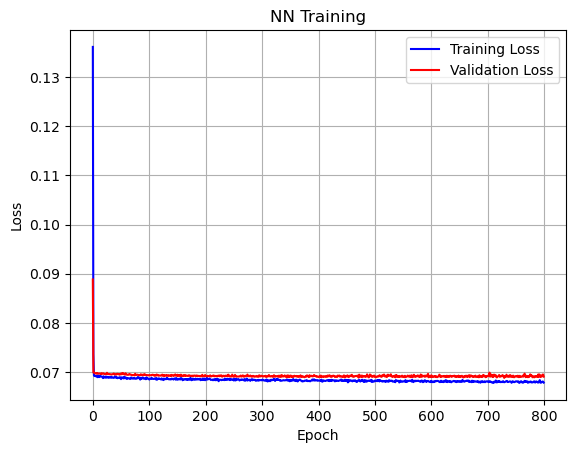

CPU times: user 5min 10s, sys: 2.07 s, total: 5min 12s
Wall time: 5min 28s


In [17]:
%%time
if generate_new_data:
    val_losses = []
    losses = []
    early_stopper = EarlyStopping()

    for num_epoch in range(800):
        epoch_loss = 0
        total_batch = 0

        for batch_inputs, batch_labels in dataloader:
            train_x = batch_inputs.flatten(start_dim=1, end_dim=2).to(device)
            train_y = batch_labels.to(device)
            outputs = model(train_x)
            loss = criterion(outputs, train_y)
            epoch_loss += loss.item()
            total_batch += 1
            loss.backward()
            optimizer_nn.step()
            optimizer_nn.zero_grad()

        val_x = inputs_val.flatten(start_dim=1, end_dim=2).to(device)
        val_y = labels_val.to(device)
        model.eval()
        with torch.no_grad():
            val_output = model(val_x)
            val_loss = criterion(val_output, val_y)
        model.train()

        val_losses.append(val_loss.item())
        early_stopper(val_loss)

        if (num_epoch + 1) % 100 == 0:
            print(f"Training {int((num_epoch + 1) / 10)}%  val_loss={val_loss:.4f}")

        losses.append(epoch_loss / total_batch)

    plt.plot(losses,     color="blue", label="Training Loss")
    plt.plot(val_losses, color="red",  label="Validation Loss")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid()
    plt.title("NN Training"); plt.show()

    torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

## Evaluate Reconstruction

In [18]:
model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [19]:
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])
E_lb,  theta_lb,  phi_lb  = DenormalizeLabels(labels_test[:, 0], labels_test[:, 1], labels_test[:, 2])
E_p, E_r     = E_pred,     E_lb
Th_p, Th_r   = theta_pred, theta_lb
Ph_p, Ph_r   = phi_pred,   phi_lb

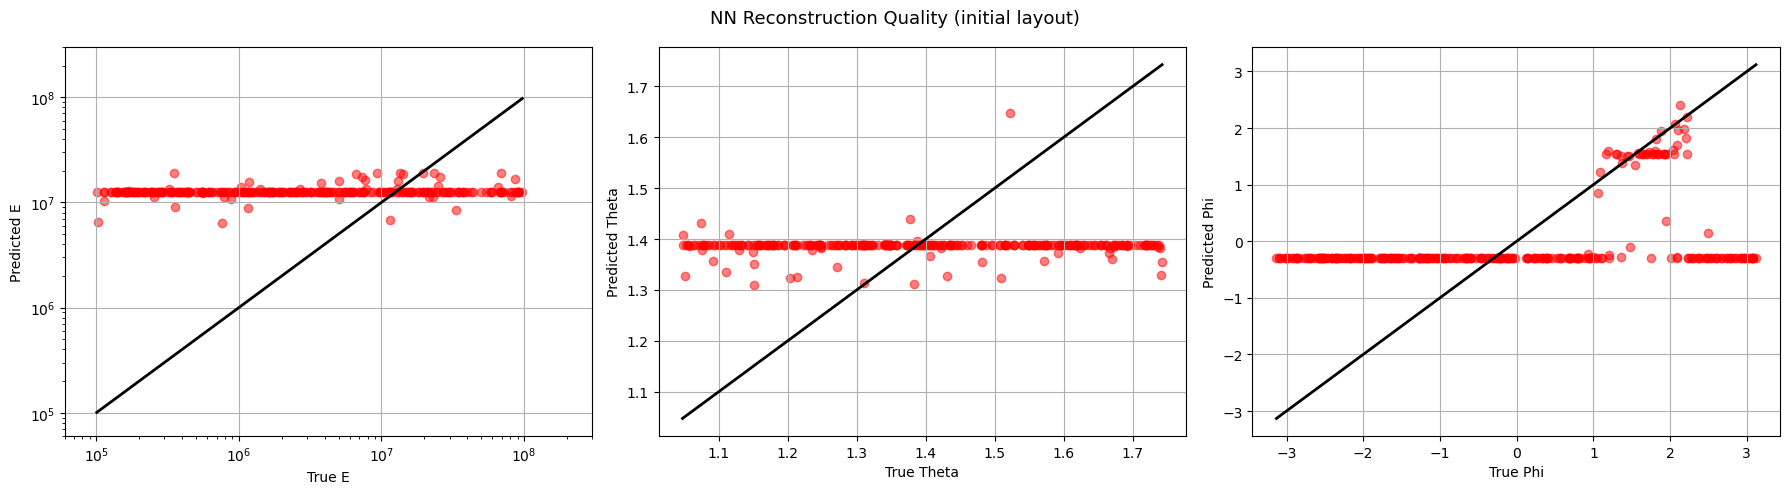

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([E_r.min().cpu(), E_r.max().cpu()], [E_r.min().cpu(), E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlim([6e4, 3e8])
axes[0].set_ylim([6e4, 3e8])

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([Th_r.min().cpu(), Th_r.max().cpu()], [Th_r.min().cpu(), Th_r.max().cpu()], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([Ph_r.min().cpu(), Ph_r.max().cpu()], [Ph_r.min().cpu(), Ph_r.max().cpu()], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.suptitle("NN Reconstruction Quality (initial layout)", fontsize=13)
plt.tight_layout(); plt.show()

## Load/Initialize Model for Optimization

In [21]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

model = Reconstruction(
    input_features=NUM_FEATURES,
    num_detectors=Nunits,
).to(device)

path = Path(f"{output_dir}/checkpoint.pth")
if path.exists():
    checkpoint = torch.load(f"{output_dir}/checkpoint.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Checkpoint weights loaded")
else:
    model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
    print("Initial NN weights loaded")

Initial NN weights loaded


## Initialize Learnable Layout

In [22]:
e = 0
os.makedirs(f"{output_dir}/Python_Layout", exist_ok=True)

# Compute and save initial layout (3 columns: N, Up, z_cont)
with torch.no_grad():
    east_0 = surface(x_det, y_det)
    zc_0   = (mountain.east_entry - east_0) / mountain.layer_east_dx
np.savetxt(f"{output_dir}/Python_Layout/Layout_0.txt",
           np.column_stack((x_det.cpu().numpy(), y_det.cpu().numpy(), zc_0.cpu().numpy())))

In [23]:
# Resume from last saved layout if available
for i in range(1000):
    p_layout = Path(f"{output_dir}/Python_Layout/Layout_{i + 1}.txt")
    if p_layout.exists():
        data = np.loadtxt(p_layout)
        x_det = torch.tensor(data[:, 0], dtype=torch.float32, device=device)
        y_det = torch.tensor(data[:, 1], dtype=torch.float32, device=device)
        e = i + 1

if e > 0:
    print(f"Resumed from Layout_{e}")
else:
    print("Starting from initial layout")

xy_module = LearnableXY(x_det, y_det, device=device)

Starting from initial layout


## Layout Optimization Loop

In [24]:
input_std  = input_std.to(device)
input_mean = input_mean.to(device)

In [25]:
SWGOopt = True
# optimizer = torch.optim.SGD(xy_module.parameters(), lr=5, momentum=.3)
optimizer = torch.optim.Adam(                  
      xy_module.parameters(),               
      lr=1,              
      betas=(0.9, 0.999),                                                                                                                                                                                                                                                                          
      eps=1e-8,                           
  )        

if path.exists():
    checkpoint = torch.load(path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    num_epoch = checkpoint.get("epoch") + 1
    print(f"Optimizer resumed from epoch {num_epoch}")
else:
    num_epoch = 0
    print("Optimizer initialized from scratch")

U_vals    = []
U_th_vals = []
U_phi_vals = []
U_e_vals  = []
U_pr_vals = []
x_det_opt: torch.Tensor = torch.tensor([])
y_det_opt: torch.Tensor = torch.tensor([])

Optimizer initialized from scratch


In [26]:
%%time
for epoch in range(num_epoch, num_epoch + training_epochs):

    if epoch < 20:
        Nfinetune = 300 # 0
        use_cache = False
    else:
        Nfinetune = 600 # 0
        use_cache = False

    x_det_opt, y_det_opt = xy_module()

    # ── Mountain surface map: derive East and z_cont from learnable (N, Up) ──
    east_det = surface(x_det_opt, y_det_opt)                        # (n_det,)
    z_cont   = (mountain.east_entry - east_det) / mountain.layer_east_dx   # (n_det,)  ∈ [0, 23]

    N_list, T_list, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(
        x_det_opt, y_det_opt, z_cont, False, number_of_showers=Nbatch, use_cache=use_cache
    )

    th = torch.atan2(sin_z, cos_z).to(device)
    ph = torch.atan2(sin_a, cos_a).to(device)

    X0 /= 5000
    Y0 /= 5000

    x_det_opt_exp = x_det_opt.unsqueeze(0).repeat(Nbatch, 1)
    y_det_opt_exp = y_det_opt.unsqueeze(0).repeat(Nbatch, 1)
    z_cont_exp    = z_cont.unsqueeze(0).repeat(Nbatch, 1)
    x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

    # 7-feature input: [x=N, y=Up, z=z_cont, N_int, T_int, x0, y0]
    # inputs_batch = torch.stack(
    #     [x_det_opt_exp, y_det_opt_exp, z_cont_exp, N_list, T_list, x0_exp, y0_exp], dim=2
    # ).float()
    inputs_batch = torch.stack(
        [x_det_opt_exp, y_det_opt_exp, z_cont_exp, N_list, T_list], dim=2
    ).float()

    # Use the FROZEN training-time normalization (computed in cell 27 over 20k
    # showers).  Updating per-batch during optimization causes a discontinuity
    # in the NN input distribution → spurious large gradient steps.
    inputs_batch_norm = (inputs_batch - input_mean) / input_std

    model.eval()
    preds_batch = model(inputs_batch_norm.view(Nbatch, -1))
    preds_e, preds_th, preds_phi = DenormalizeLabels(
        preds_batch[:, 0], preds_batch[:, 1], preds_batch[:, 2]
    )

    # N_int is at feature index 3
    r_score = reconstructability(inputs_batch[:, :, 3], reconstruct_threshold=10)
    U = (
        U_angle(preds_th,  th, r_score) +
        U_angle(preds_phi, ph, r_score) + 
        U_E(preds_e, energy, r_score)   + 0
        # 5e5 * U_PR(r_score)
    )

    U_vals.append(U.item())
    U_th_vals.append(  ( U_angle(preds_th,  th, r_score)).item() )
    U_phi_vals.append( ( U_angle(preds_phi, ph, r_score)).item() )
    U_e_vals.append(   ( U_E(preds_e, energy, r_score)).item() )
    U_pr_vals.append(  ( U_PR(r_score)).item() )

    print(f"Epoch {epoch}  U={U:.3f}  z_cont=[{z_cont.min():.1f},{z_cont.max():.1f}]")

    if not torch.isfinite(U):                                                                                                                                                                                                                                                           
          print(f"  ⚠ non-finite U at epoch {epoch} — skipping backward/step")                                                                                                                                                                                                          
          optimizer.zero_grad(set_to_none=True)                                                                                                                                                                                                                                           
          continue
    
    Loss = -U
    Loss.backward()

    for name, p in xy_module.named_parameters():
        gn = p.grad.norm().item() if p.grad is not None else "None"
        print(f"  {name}: grad_norm={gn}")

    torch.nn.utils.clip_grad_norm_(xy_module.parameters(), max_norm=100.0)
    optimizer.step()
    optimizer.zero_grad()

    # ── Project detectors back onto the mountain surface ────────────────────
    # A rectangular bbox clamp would let detectors sit in bbox corners outside
    # the actual mountain footprint (where SurfaceEastMap's nearest-neighbour
    # fallback gives visually misleading East values).  Instead, snap any
    # detector whose nearest centroid is farther than max_gap to that nearest
    # centroid's (N, Up).
    with torch.no_grad():
        N_proj, U_proj = mountain.project_to_mountain(xy_module.x.data, xy_module.y.data)
        xy_module.x.data.copy_(N_proj)
        xy_module.y.data.copy_(U_proj)

    # ── NN fine-tune every 5 epochs ───────────────────────────────────────────
    if (epoch + 1) % 5 == 0:
        model.zero_grad()
        print(f"Fine-tune at epoch {epoch + 1}")

        with torch.no_grad():
            x_ft, y_ft = xy_module()
            east_ft = surface(x_ft, y_ft)
            zc_ft   = (mountain.east_entry - east_ft) / mountain.layer_east_dx

            N, T, X0_ft, Y0_ft, energy_ft, sin_z_ft, cos_z_ft, sin_a_ft, cos_a_ft, _ =                 generate_showers(x_ft, y_ft, zc_ft, False,
                                 number_of_showers=Nfinetune, use_cache=use_cache)

            theta_ft = torch.atan2(sin_z_ft, cos_z_ft)
            phi_ft   = torch.atan2(sin_a_ft, cos_a_ft)
            e_norm, th_norm, ph_norm = NormalizeLabels(energy_ft, theta_ft, phi_ft)

            X0_ft /= 5000; Y0_ft /= 5000
            labels_ft = torch.stack([e_norm, th_norm, ph_norm], dim=1).float()

            x_ft_exp  = x_ft.unsqueeze(0).expand(Nfinetune, -1)
            y_ft_exp  = y_ft.unsqueeze(0).expand(Nfinetune, -1)
            zc_ft_exp = zc_ft.unsqueeze(0).expand(Nfinetune, -1)
            x0_ft = X0_ft.unsqueeze(1).expand(-1, Nunits)
            y0_ft = Y0_ft.unsqueeze(1).expand(-1, Nunits)

            # inputs_ft = torch.stack(
            #     [x_ft_exp, y_ft_exp, zc_ft_exp, N, T, x0_ft, y0_ft], dim=2
            # ).float()
            inputs_ft = torch.stack(
                [x_ft_exp, y_ft_exp, zc_ft_exp, N, T], dim=2
            ).float()

            # Same as the main loop: keep the frozen training-time normalization.
            inputs_ft = (inputs_ft - input_mean) / input_std

        ReconstructionNN = model
        ReconstructionNN.train()
        criterion_ft = nn.MSELoss()
        optimizer_ft = torch.optim.Adam(ReconstructionNN.parameters(), lr=1e-6)

        ft_dataset    = TensorDataset(inputs_ft, labels_ft)
        ft_dataloader = DataLoader(ft_dataset, batch_size=32, shuffle=True,
                                   drop_last=False, num_workers=0)
        for j in range(5):
            for inputs_b, labels_b in ft_dataloader:
                bsz = inputs_b.size(0)
                out_ft = ReconstructionNN(inputs_b.view(bsz, -1).to(device))
                loss_ft = criterion_ft(out_ft, labels_b.view(bsz, 3).to(device))
                loss_ft.backward()
                optimizer_ft.step()
                optimizer_ft.zero_grad()

    # ── Save checkpoint and layout ────────────────────────────────────────────
    torch.save({"epoch": epoch, "loss": Loss.cpu(),
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()},
               f"{output_dir}/checkpoint.pth")

    # 3-column layout file: North, Up, z_cont
    np.savetxt(f"{output_dir}/Python_Layout/Layout_{epoch + 1}.txt",
               np.column_stack((
                   x_det_opt.detach().cpu().numpy(),
                   y_det_opt.detach().cpu().numpy(),
                   z_cont.detach().cpu().numpy(),
               )))
    # Save utilities incrementally (survives SLURM preemption)
    # Columns: U_total, U_theta, U_phi, U_E, U_PR
    utility_path = Path(f"{output_dir}/Python_Layout/Utilities.txt")
    u_row = np.array([[U_vals[-1], U_th_vals[-1], U_phi_vals[-1], U_e_vals[-1], U_pr_vals[-1]]])
    if utility_path.exists():
        u_prev = np.loadtxt(utility_path, ndmin=2)
        np.savetxt(utility_path, np.vstack([u_prev, u_row]),
                   header="U_total U_theta U_phi U_E U_PR")
    else:
        np.savetxt(utility_path, u_row,
                   header="U_total U_theta U_phi U_E U_PR")


  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 807.1 ms
  Running inference on 500 samples ...


  Inference done in 1.28 s
  Mean total hits predicted per shower: 1990.3
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.05 s
  Time mode: ON (x,y,e,t)
  Generating 500 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[   864s]: start batch   0


[   864s]: start batch   1


[   865s]: start batch   2


...

[  4177s]: start batch  18


[  4178s]: start batch  19


[  4178s]: generation done


  Generation done in 7.96 s
samples shape: torch.Size([600, 2048, 5])


CPU times: user 48min 5s, sys: 6min 37s, total: 54min 43s
Wall time: 55min 16s


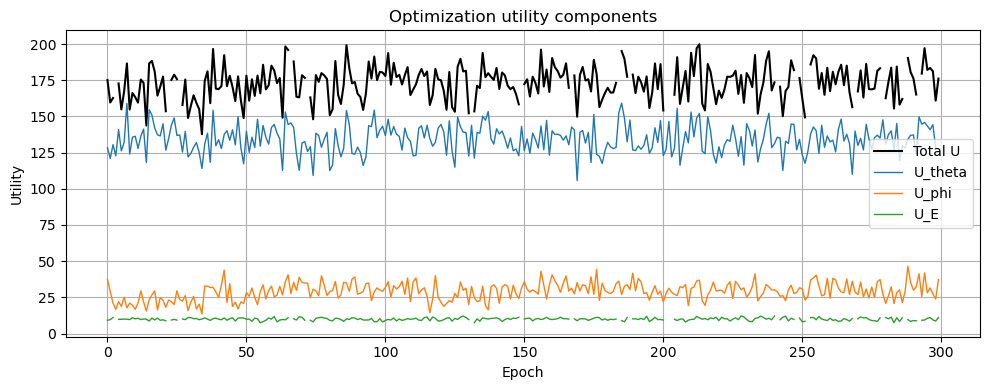

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(U_vals,  label='Total U', color='black', lw=1.5)
plt.plot([u for u in U_th_vals],  label='U_theta',  lw=1)
plt.plot([u for u in U_phi_vals], label='U_phi',   lw=1)
plt.plot([u for u in U_e_vals],   label='U_E',    lw=1)
# plt.plot([u for u in U_pr_vals],  label='5e5 U_PR',    lw=1)
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Utility"); plt.grid()
# plt.yscale("log")
plt.title("Optimization utility components"); plt.tight_layout(); plt.show()

## Visualize Results

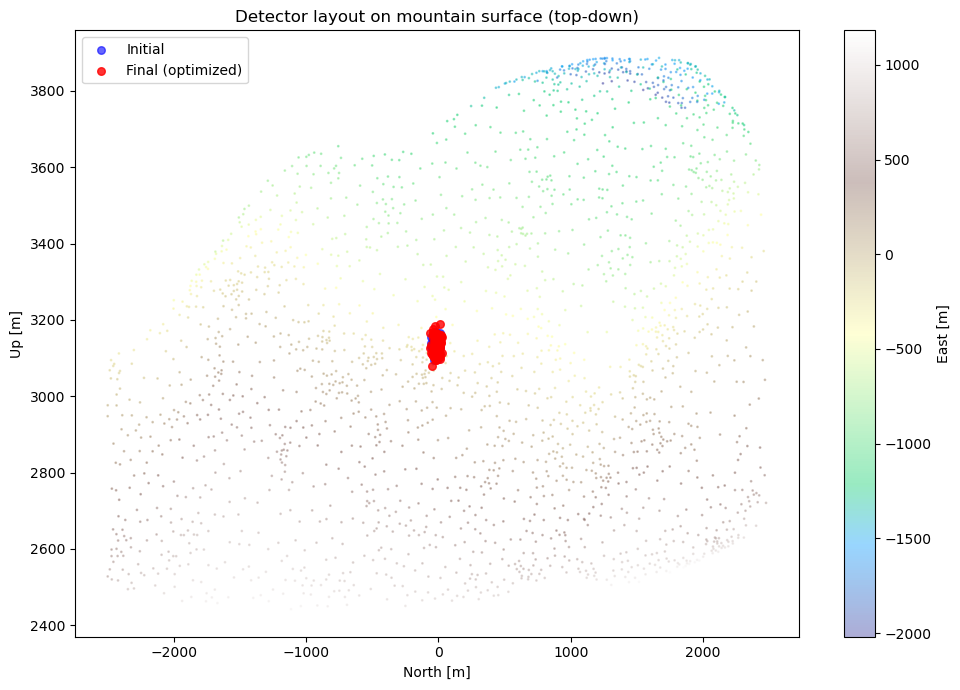

In [28]:
# Top-down (N, Up) view: mountain background + optimized detectors
fig, ax = plt.subplots(figsize=(10, 7))
N_mtn  = mountain.centroids_NUE[:, 0]
Up_mtn = mountain.centroids_NUE[:, 1]
East_mtn = mountain.centroids_NUE[:, 2]
sc_bg = ax.scatter(N_mtn, Up_mtn, c=East_mtn, s=1, cmap='terrain', alpha=0.4)
plt.colorbar(sc_bg, ax=ax, label='East [m]')

x_final = x_det_opt.detach().cpu().numpy()
y_final = y_det_opt.detach().cpu().numpy()

with torch.no_grad():
    east_final = surface(x_det_opt.detach(), y_det_opt.detach()).detach()
    zc_final   = (mountain.east_entry - east_final) / mountain.layer_east_dx

ax.scatter(N_init, U_init,          c='blue',  s=30, alpha=.6, label='Initial')
ax.scatter(x_final, y_final,        c='red',   s=30, alpha=.8, label='Final (optimized)')
ax.set_xlabel("North [m]"); ax.set_ylabel("Up [m]")
ax.set_title("Detector layout on mountain surface (top-down)")
ax.legend(); plt.tight_layout(); plt.show()

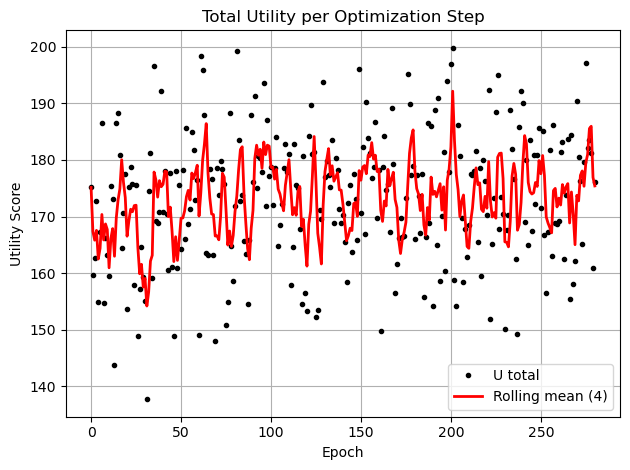

In [29]:
u_t = np.vstack([u_prev, u_row])
# Plot all components
mean_ut = [np.mean(u_t[max(0, i-4):i, 0]) for i in range(1, len(u_t)+1)]
plt.plot(u_t[:, 0], color="black", linestyle="none", marker="o", lw=.5, ms=3, label="U total")
plt.plot(mean_ut, color="red", lw=2, label="Rolling mean (4)")
plt.legend(); plt.grid()
plt.xlabel("Epoch"); plt.ylabel("Utility Score")
plt.title("Total Utility per Optimization Step"); plt.tight_layout(); plt.show()

## 3D Scatter on Mountain Surface

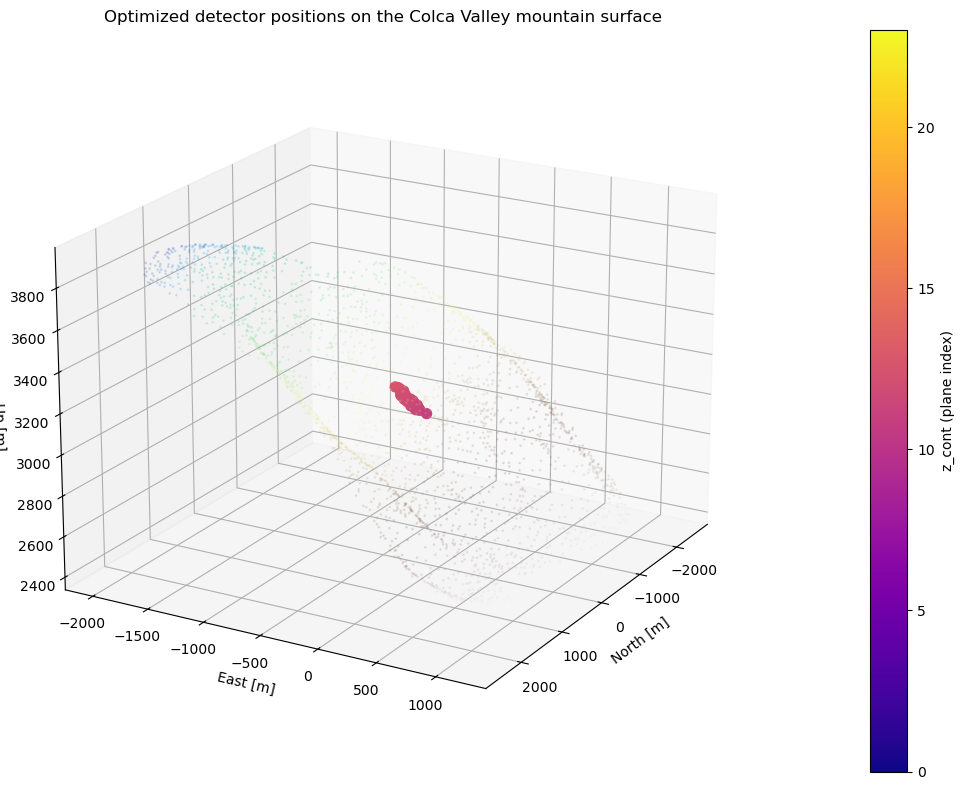

In [30]:
fig = plt.figure(figsize=(12, 8))
ax3 = fig.add_subplot(111, projection='3d')

# Axes: x=North, y=East, z=Up  (Up is the vertical axis)
ax3.scatter(N_mtn, East_mtn, Up_mtn, c=East_mtn, cmap='terrain',
            s=1, alpha=0.15, depthshade=True)

sc_det = ax3.scatter(
    x_final, east_final.cpu().numpy(), y_final,
    c=zc_final.cpu().numpy(), cmap='plasma',
    vmin=0, vmax=N_PLANES - 1, s=50, zorder=5, depthshade=False
)
plt.colorbar(sc_det, ax=ax3, label='z_cont (plane index)', pad=0.1)

ax3.view_init(elev=20, azim=30)
ax3.set_xlabel("North [m]"); ax3.set_ylabel("East [m]"); ax3.set_zlabel("Up [m]")
ax3.set_title("Optimized detector positions on the Colca Valley mountain surface")
plt.tight_layout(); plt.show()

## Animation: Detectors Sliding on Mountain

In [31]:
%%capture
from matplotlib import animation
from IPython.display import HTML

layout_dir = Path(f"{output_dir}/Python_Layout")
layout_files = sorted(layout_dir.glob("Layout_*.txt"),
                      key=lambda p: int(p.stem.split("_")[1]))

step_sample = 5  # use every 5th saved layout
layouts = [np.loadtxt(f) for f in layout_files[::step_sample]]
print(f"Loaded {len(layouts)} layout frames")

N_mtn_a  = mountain.centroids_NUE[:, 0]
Up_mtn_a = mountain.centroids_NUE[:, 1]
East_mtn_a = mountain.centroids_NUE[:, 2]

fig_a = plt.figure(figsize=(11, 7))
ax_a  = fig_a.add_subplot(111, projection='3d')

# Static mountain background (drawn once)
ax_a.scatter(N_mtn_a, East_mtn_a, Up_mtn_a, c=East_mtn_a, cmap='terrain',
             s=1, alpha=0.15, depthshade=True)
ax_a.set_xlabel("North [m]"); ax_a.set_ylabel("East [m]"); ax_a.set_zlabel("Up [m]")
ax_a.view_init(elev=20, azim=30)


# Animated detector scatter — initialize with first frame
lay0 = layouts[0]
N_d0, Up_d0, zc_d0 = lay0[:, 0], lay0[:, 1], lay0[:, 2]
East_d0 = mountain.east_entry - zc_d0 * mountain.layer_east_dx
det_scatter = ax_a.scatter(N_d0, East_d0, Up_d0, c=zc_d0, cmap='plasma',
                           vmin=0, vmax=N_PLANES - 1, s=40, zorder=5, depthshade=False)
title_obj = ax_a.set_title("Step 0")


def _update(frame):
    lay = layouts[frame]
    N_d, Up_d, zc_d = lay[:, 0], lay[:, 1], lay[:, 2]
    East_d = mountain.east_entry - zc_d * mountain.layer_east_dx
    det_scatter._offsets3d = (N_d, East_d, Up_d)
    det_scatter.set_array(zc_d)
    title_obj.set_text(f"Step {frame * step_sample}")
    return det_scatter, title_obj


anim = animation.FuncAnimation(fig_a, _update, frames=len(layouts), interval=120, blit=False)

gif_path = Path(output_dir) / "layout_evolution_3d.gif"
anim.save(str(gif_path), writer="pillow", fps=8, dpi=100)
plt.close(fig_a)
print(f"Saved {gif_path}")

In [32]:
# HTML(anim.to_jshtml())

## Evaluate Reconstruction (final layout)

In [33]:
x, y = x_det_opt, y_det_opt
with torch.no_grad():
    east_eval = surface(x, y)
    zc_eval   = (mountain.east_entry - east_eval) / mountain.layer_east_dx
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(
        x, y, zc_eval, False, number_of_showers=Ntest, use_cache=use_cache
    )

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)
E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000; y0 = Y0 / 5000
z_exp   = zc_eval.unsqueeze(0).expand(Ntest, -1)
x_det_exp = x.unsqueeze(0).expand(Ntest, -1)
y_det_exp = y.unsqueeze(0).expand(Ntest, -1)
x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
y0_exp = y0.unsqueeze(1).expand(-1, Nunits)
# inputs_test_final = torch.stack([x_det_exp, y_det_exp, z_exp, N, T, x0_exp, y0_exp], dim=2).float()
inputs_test_final = torch.stack([x_det_exp, y_det_exp, z_exp, N, T], dim=2).float()
labels_test_final = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

  Loading PointCountFM from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/num_of_point_clouds_dequantize_compiled.pt ...


  Loaded in 628.9 ms
  Running inference on 300 samples ...


  Inference done in 0.87 s
  Mean total hits predicted per shower: 1986.2
  Loading AllShowers generator from /n/home05/zdimitrov/tambo/TAMBO-opt/allshowers/checkpoints/all_showers ...
  Loaded in 0.05 s
  Time mode: ON (x,y,e,t)
  Generating 300 showers (16 ODE steps, solver=midpoint, device=cuda) ...
[  4219s]: start batch   0


[  4219s]: start batch   1


[  4220s]: start batch   2


...

[  4222s]: start batch   7


[  4222s]: start batch   8


[  4223s]: start batch   9


[  4223s]: generation done


  Generation done in 3.96 s
samples shape: torch.Size([300, 2048, 5])


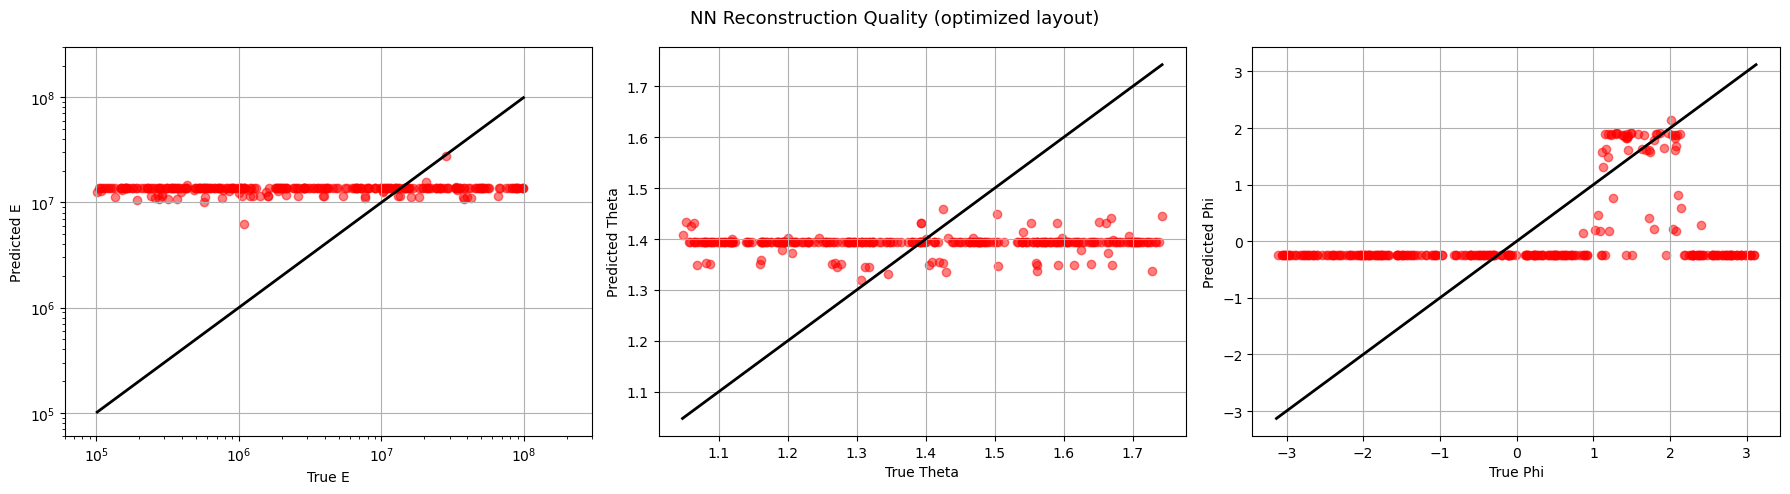

In [34]:
model.eval()
with torch.no_grad():
    inputs_n = (inputs_test_final.cpu() - input_mean.cpu()) / input_std.cpu()
    outputs = model(inputs_n.view(Ntest, -1).to(device)).cpu()

E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])
E_lb,  theta_lb,  phi_lb  = DenormalizeLabels(
    labels_test_final[:, 0], labels_test_final[:, 1], labels_test_final[:, 2]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(E_lb.cpu(), E_pred.cpu(), alpha=.5, color="r")
axes[0].plot([E_lb.detach().cpu().min(), E_lb.detach().cpu().max()], [E_lb.detach().cpu().min(), E_lb.detach().cpu().max()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlim([6e4, 3e8])
axes[0].set_ylim([6e4, 3e8])

axes[1].scatter(theta_lb.cpu(), theta_pred.detach().cpu(), alpha=.5, color="r")
axes[1].plot([Th_r.min().cpu(), Th_r.max().cpu()], [Th_r.min().cpu(), Th_r.max().cpu()], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(phi_lb.cpu(), phi_pred.detach().cpu(), alpha=.5, color="r")
axes[2].plot([Ph_r.min().cpu(), Ph_r.max().cpu()], [Ph_r.min().cpu(), Ph_r.max().cpu()], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.suptitle("NN Reconstruction Quality (optimized layout)", fontsize=13)
plt.tight_layout(); plt.show()